In [1]:
# --- Load Kepler Dataset ---
import os
import kagglehub
import pandas as pd
pd.options.display.float_format = '{:.2f}'.format

# 1. Download the latest version of the dataset
path = kagglehub.dataset_download("nasa/kepler-exoplanet-search-results")

# 2. Define the target file name
file_name = "cumulative.csv"

# 3. Combine the directory path with the file name
full_path = os.path.join(path, file_name)

# 4. Load the dataset into a pandas DataFrame
df = pd.read_csv(full_path)

# 5. Verify the shape of the dataset
print("Dataset loaded successfully!")
print(f"Shape of the dataset (rows, columns): {df.shape}")

Dataset loaded successfully!
Shape of the dataset (rows, columns): (9564, 50)


In [2]:
df['koi_disposition'].unique()

<ArrowStringArray>
['CONFIRMED', 'FALSE POSITIVE', 'CANDIDATE']
Length: 3, dtype: str

In [3]:
df['koi_pdisposition'].unique()

<ArrowStringArray>
['CANDIDATE', 'FALSE POSITIVE']
Length: 2, dtype: str

In [4]:
# --- Features before preprocessing ---
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9564 entries, 0 to 9563
Data columns (total 50 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   rowid              9564 non-null   int64  
 1   kepid              9564 non-null   int64  
 2   kepoi_name         9564 non-null   str    
 3   kepler_name        2294 non-null   str    
 4   koi_disposition    9564 non-null   str    
 5   koi_pdisposition   9564 non-null   str    
 6   koi_score          8054 non-null   float64
 7   koi_fpflag_nt      9564 non-null   int64  
 8   koi_fpflag_ss      9564 non-null   int64  
 9   koi_fpflag_co      9564 non-null   int64  
 10  koi_fpflag_ec      9564 non-null   int64  
 11  koi_period         9564 non-null   float64
 12  koi_period_err1    9110 non-null   float64
 13  koi_period_err2    9110 non-null   float64
 14  koi_time0bk        9564 non-null   float64
 15  koi_time0bk_err1   9110 non-null   float64
 16  koi_time0bk_err2   9110 non-null   

In [5]:
# --- Telescope Calibration & Data Purge ---
# 1. Define the complete list of columns to exclude (Metadata + Data Leakage)
columns_to_drop = [

    # --- METADATA (Identifiers & System Indices) ---
    # These columns contain no physical information. Keeping them could cause
    # the machine learning model to memorize database IDs instead of learning physics.
    'rowid',              # Sequential database index
    'kepid',              # Kepler Target Star ID number
    'kepoi_name',         # KOI alphanumeric identifier (e.g., K00752.01)
    'koi_tce_delivname',  # Technical name of the NASA software pipeline
    'koi_tce_plnt_num',   # Sequential index of the planet within its specific star system

    # --- DATA LEAKAGE (Answers from the future) ---
    # These columns contain target information assigned after the fact.
    # Keeping them would allow the model to "cheat" during training.
    'kepler_name',        # Official planetary name (assigned ONLY to 100% confirmed planets)
    'koi_pdisposition',   # NASA pipeline's initial automated classification
    'koi_score',          # NASA's calculated probability score of being a confirmed planet

    # --- DATA LEAKAGE (Post-analysis diagnostic flags) ---
    # These flags are conclusions made by scientists/algorithms to explain *why* # an object is a false positive. We must drop them to force our model to learn independently.
    'koi_fpflag_nt',      # Flag: Not a Transit (light curve doesn't match a planetary transit)
    'koi_fpflag_ss',      # Flag: Stellar Eclipse (binary stars mimicking a giant planet)
    'koi_fpflag_co',      # Flag: Centroid Offset (light dip comes from a background source)
    'koi_fpflag_ec'       # Flag: Ephemeris Match (signal matches a known instrument artifact)
]

# 2. Drop the specified columns from the dataset
# Using 'columns=' explicitly tells pandas to drop vertical features, not rows.
df_clean = df.drop(columns=columns_to_drop)

# 3. Verify the operation
print(f"Columns before cleaning: {df.shape[1]}")
print(f"Columns after total cleaning: {df_clean.shape[1]}")
print("Metadata and data leakage columns successfully removed.")

Columns before cleaning: 50
Columns after total cleaning: 38
Metadata and data leakage columns successfully removed.


In [6]:
# --- Features during preprocessing ---
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 9564 entries, 0 to 9563
Data columns (total 38 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   koi_disposition    9564 non-null   str    
 1   koi_period         9564 non-null   float64
 2   koi_period_err1    9110 non-null   float64
 3   koi_period_err2    9110 non-null   float64
 4   koi_time0bk        9564 non-null   float64
 5   koi_time0bk_err1   9110 non-null   float64
 6   koi_time0bk_err2   9110 non-null   float64
 7   koi_impact         9201 non-null   float64
 8   koi_impact_err1    9110 non-null   float64
 9   koi_impact_err2    9110 non-null   float64
 10  koi_duration       9564 non-null   float64
 11  koi_duration_err1  9110 non-null   float64
 12  koi_duration_err2  9110 non-null   float64
 13  koi_depth          9201 non-null   float64
 14  koi_depth_err1     9110 non-null   float64
 15  koi_depth_err2     9110 non-null   float64
 16  koi_prad           9201 non-null   

In [7]:
# --- Missing Values Audit ---
# 1. Compute the number of missing values for each column in df_clean
missing_counts = df_clean.isnull().sum()

# 2. Compute the percentage of missing values
missing_percentage = (df_clean.isnull().sum() / len(df_clean)) * 100

# 3. Create a summary DataFrame for columns containing at least one NaN
missing_df = pd.DataFrame({
    'Missing Values': missing_counts,
    'Percentage (%)': missing_percentage
})

# Keep only variables with missing data and sort by severity
missing_df = missing_df[missing_df['Missing Values'] > 0] \
    .sort_values(by='Missing Values', ascending=False)

# 4. Display the report
if len(missing_df) > 0:
    print(missing_df)
else:
    print("No missing values found in df_clean!")

                   Missing Values  Percentage (%)
koi_teq_err2                 9564          100.00
koi_teq_err1                 9564          100.00
koi_steff_err2                483            5.05
koi_srad_err2                 468            4.89
koi_steff_err1                468            4.89
koi_slogg_err1                468            4.89
koi_slogg_err2                468            4.89
koi_srad_err1                 468            4.89
koi_period_err1               454            4.75
koi_period_err2               454            4.75
koi_time0bk_err1              454            4.75
koi_time0bk_err2              454            4.75
koi_impact_err1               454            4.75
koi_impact_err2               454            4.75
koi_duration_err1             454            4.75
koi_duration_err2             454            4.75
koi_depth_err1                454            4.75
koi_depth_err2                454            4.75
koi_teq                       363            3.80


In [8]:
# --- Missing value imputation and feature separation ---
# 1. Prepare df_imputed as a clean copy of df_clean
df_imputed = df_clean.copy()

# 2. Drop the columns that are 100% empty
empty_cols = ['koi_teq_err1', 'koi_teq_err2']
df_imputed = df_imputed.drop(columns=[c for c in empty_cols if c in df_imputed.columns])

# 3. Identify and fill numerical columns with the median
numeric_cols = df_imputed.select_dtypes(include=['float64', 'int64']).columns
for col in numeric_cols:
    median_value = df_imputed[col].median()
    df_imputed[col] = df_imputed[col].fillna(median_value)

# 4. Feature Separation (Numerical vs. Categorical)
# We isolate the physics (numeric) from the labels (categorical)
numerical_vars = df_imputed.select_dtypes(include=['float64', 'int64']).columns
categorical_vars = df_imputed.select_dtypes(include=['object']).columns

df_num = df_imputed[numerical_vars].copy()
df_cat = df_imputed[categorical_vars].copy()

# 5. Final Verification
total_missing = df_imputed.isnull().sum().sum()
print(f"Total missing values remaining: {total_missing}")
print(f"Numerical features: {df_num.shape[1]}")
print(f"Categorical features: {df_cat.shape[1]}")
print("Calibration complete!")

Total missing values remaining: 0
Numerical features: 35
Categorical features: 1
Calibration complete!


/tmp/ipykernel_7931/4059220399.py:18: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_vars = df_imputed.select_dtypes(include=['object']).columns


In [9]:
# --- Features after preprocessing ---
df_imputed.info()

<class 'pandas.DataFrame'>
RangeIndex: 9564 entries, 0 to 9563
Data columns (total 36 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   koi_disposition    9564 non-null   str    
 1   koi_period         9564 non-null   float64
 2   koi_period_err1    9564 non-null   float64
 3   koi_period_err2    9564 non-null   float64
 4   koi_time0bk        9564 non-null   float64
 5   koi_time0bk_err1   9564 non-null   float64
 6   koi_time0bk_err2   9564 non-null   float64
 7   koi_impact         9564 non-null   float64
 8   koi_impact_err1    9564 non-null   float64
 9   koi_impact_err2    9564 non-null   float64
 10  koi_duration       9564 non-null   float64
 11  koi_duration_err1  9564 non-null   float64
 12  koi_duration_err2  9564 non-null   float64
 13  koi_depth          9564 non-null   float64
 14  koi_depth_err1     9564 non-null   float64
 15  koi_depth_err2     9564 non-null   float64
 16  koi_prad           9564 non-null   

In [10]:
# --- Standardization of Numerical Features ---
from sklearn.preprocessing import StandardScaler

# 1. Initialize the StandardScaler
# This object computes the mean and standard deviation for each feature
scaler = StandardScaler()

# 2. Apply the transformation
# fit_transform computes parameters and scales the data in a single step
# The output is a NumPy array, which we convert back to a DataFrame to preserve labels
df_num_scaled = pd.DataFrame(
    scaler.fit_transform(df_num),
    columns=df_num.columns,
    index=df_num.index
)

# 3. Verification
# Check that mean is ~0 and standard deviation is ~1
print("Standardization complete.")
print(f"Mean of standardized data:\n{df_num_scaled.mean().head(3).values} ... (should be near 0)")
print(f"Std of standardized data:\n{df_num_scaled.std().head(3).values} ... (should be near 1)")

Standardization complete.
Mean of standardized data:
[ 3.71467344e-18  2.37739100e-17 -2.37739100e-17] ... (should be near 0)
Std of standardized data:
[1.00005228 1.00005228 1.00005228] ... (should be near 1)


In [11]:
# --- Target Label Encoding ---
from sklearn.preprocessing import LabelEncoder

# 1. Initialize the encoder
encoder = LabelEncoder()

# 2. Select the target column from the categorical dataframe (df_cat)
# We assume the column is 'koi_disposition'
target_column = 'koi_disposition'

# 3. Apply the transformation
# The encoder learns unique categories and maps them to integers (e.g., 0, 1, 2)
y = encoder.fit_transform(df_cat[target_column])

# 4. Check the mapping
# It is important to know which number corresponds to which original label
mapping = dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))
print("Label encoding mapping:")
print(mapping)

# 5. (Optional) Inspect the resulting encoded values
print(f"\nFirst 10 encoded labels: {y[:50]}")

Label encoding mapping:
{'CANDIDATE': np.int64(0), 'CONFIRMED': np.int64(1), 'FALSE POSITIVE': np.int64(2)}

First 10 encoded labels: [1 1 2 2 1 1 1 1 2 1 1 1 1 1 2 2 2 2 1 1 2 1 1 1 2 1 1 1 2 2 2 1 1 1 1 1 1
 0 2 1 2 1 1 1 1 1 2 1 1 1]


In [12]:
# --- Dataset Recombination ---
# 1. Recombination
# Merge scaled numerical features with the target column 'koi_disposition'
# We use pd.concat to align feature matrix and target vector side by side
df_final = pd.concat(
    [df_num_scaled, pd.Series(y, name='koi_disposition', index=df_num_scaled.index)],
    axis=1
)

# 2. Verification
print(f"Final dataset shape: {df_final.shape}")
print("\nFirst rows of the final dataset:")
print(df_final.head())

# 3. Final type check
# Ensure there are no remaining 'object' types (everything should be numeric)
print("\nData types in final dataset:")
print(df_final.dtypes.value_counts())

Final dataset shape: (9564, 36)

First rows of the final dataset:
   koi_period  koi_period_err1  koi_period_err2  koi_time0bk  \
0       -0.05            -0.25             0.25         0.06   
1       -0.02            -0.22             0.22        -0.05   
2       -0.04            -0.25             0.25         0.14   
3       -0.06            -0.25             0.25         0.06   
4       -0.05            -0.25             0.25         0.08   

   koi_time0bk_err1  koi_time0bk_err2  koi_impact  koi_impact_err1  \
0             -0.33              0.33       -0.18            -0.17   
1             -0.27              0.27       -0.04            -0.20   
2             -0.40              0.40        0.07             0.35   
3             -0.42              0.42        0.17            -0.19   
4             -0.38              0.38       -0.01            -0.18   

   koi_impact_err2  koi_duration  ...  koi_slogg  koi_slogg_err1  \
0             0.15         -0.41  ...       0.36           -

In [13]:
# --- Train/Test Split ---
from sklearn.model_selection import train_test_split

# 1. Define Features (X) and Target (y)
# X contains all numerical predictors, y contains the target class
X = df_final.drop(columns=['koi_disposition'])
y = df_final['koi_disposition']

# 2. Split the dataset
# test_size=0.2 reserves 20% of the data for final testing
# random_state=42 ensures reproducibility of the split
# stratify=y preserves class distribution in both training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Check dataset sizes
print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set: {X_test.shape[0]} rows")
print("\nSplit completed. Data is ready for model training.")

Training set: 7651 rows
Test set: 1913 rows

Split completed. Data is ready for model training.


/home/leonardo/.pyenv/versions/AS/lib/python3.13/site-packages/pandas/core/nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


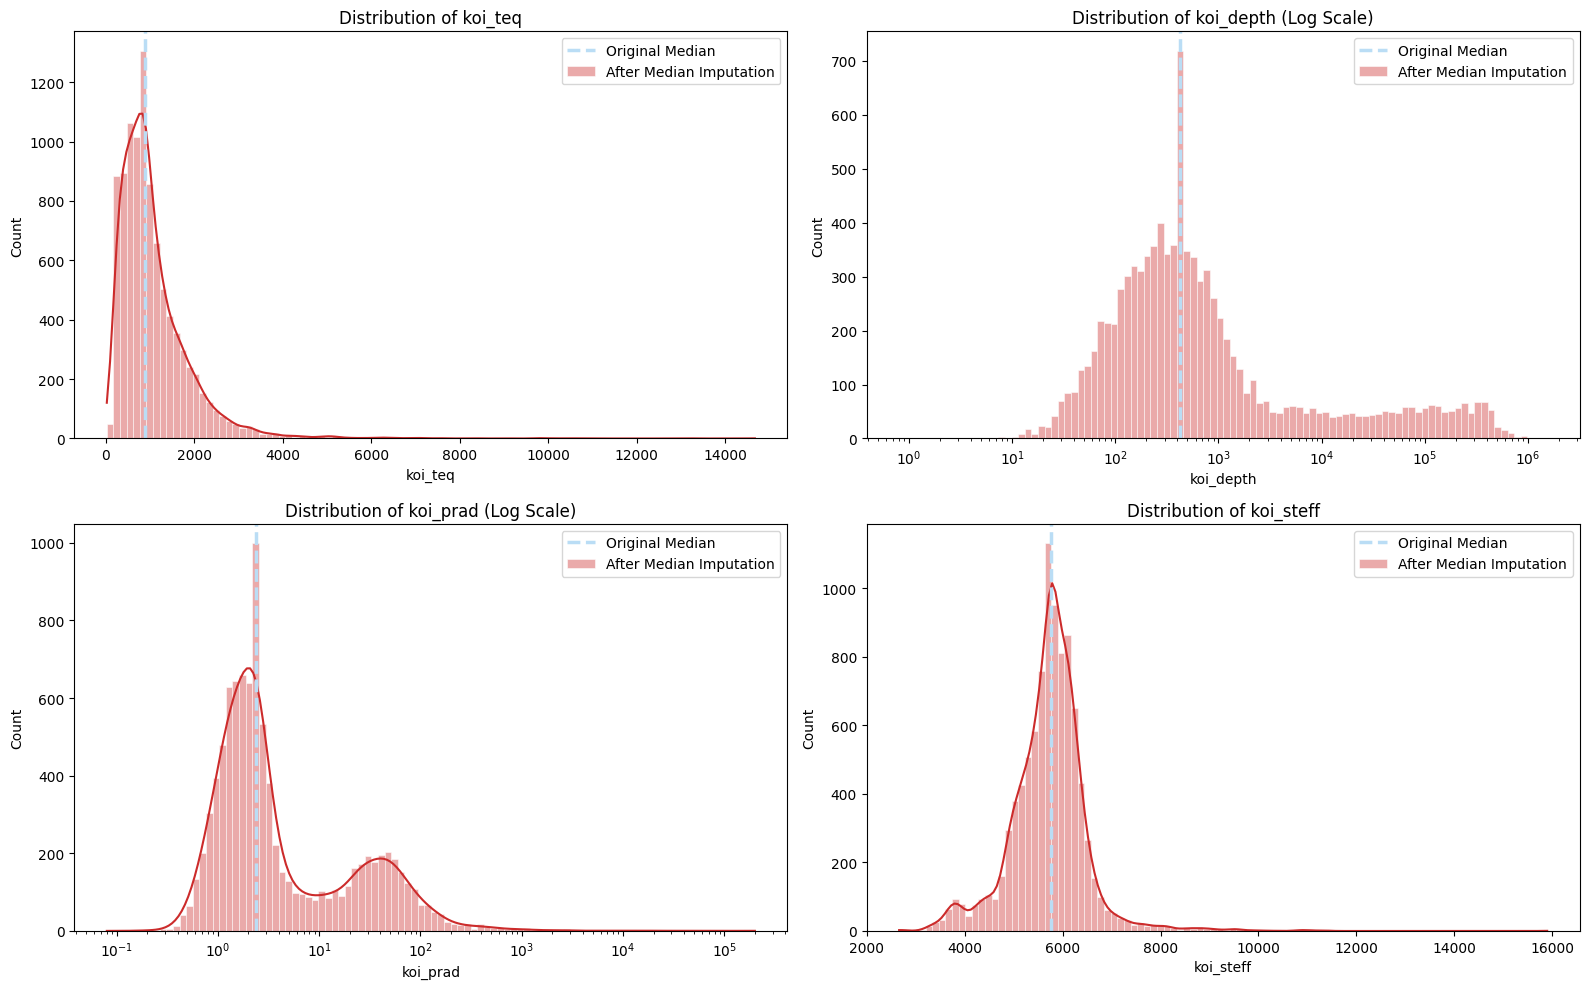

In [14]:
# --- Imputation Impact & Distribution Check ---
import seaborn as sns
import matplotlib.pyplot as plt

# Features that originally contained missing values
target_features = ['koi_teq', 'koi_depth', 'koi_prad', 'koi_steff']

# Grid configuration
nrows = 2
ncols = 2

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 10))

for i, col in enumerate(target_features):

    ax_cell = axes[i // ncols, i % ncols]

    # Use logarithmic scale for highly skewed variables
    use_log = col in ['koi_depth', 'koi_prad']

    # Distribution after imputation
    sns.histplot(
        data=df_imputed,
        x=col,
        kde=True,
        bins='sqrt',
        log_scale=use_log,
        color='#cc2b2b',
        alpha=0.4,
        edgecolor=(1, 1, 1),
        label='After Median Imputation',
        ax=ax_cell
    )

    # Original median reference line
    original_median = df_clean[col].median()

    ax_cell.axvline(
        original_median,
        color='#baddf5',
        linestyle='--',
        linewidth=2.5,
        label='Original Median'
    )

    # Titles and legends
    scale_text = " (Log Scale)" if use_log else ""
    ax_cell.set_title(f"Distribution of {col}{scale_text}")
    ax_cell.legend()

# Adjust layout and display plots
plt.tight_layout()
plt.show()

In [15]:
# --- IMPUTATION IMPACT ASSESSMENT ---
# - Log scaling successfully uncompressed right-skewed features (koi_depth, koi_prad).
# - A minor artificial spike is visible exactly at the median line for these features,
#   which is the expected footprint of median imputation.
# - Given the low percentage of missing data (~3.8%), the natural variance and
#   overall physical integrity of the variables remain intact.
# - Conclusion: The imputation strategy is confirmed safe for downstream modeling.

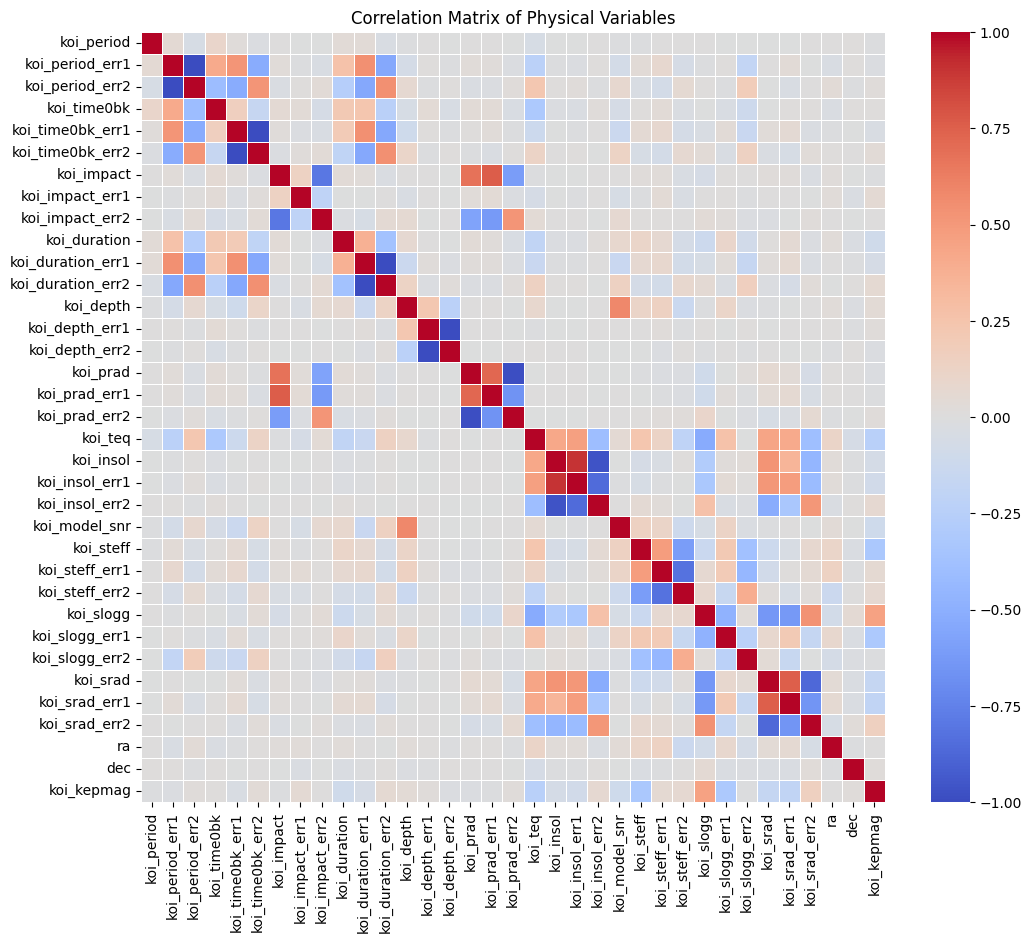

Highly correlated variable pairs (> 0.9):
[('koi_period_err1', 'koi_period_err2'), ('koi_time0bk_err1', 'koi_time0bk_err2'), ('koi_duration_err1', 'koi_duration_err2'), ('koi_depth_err1', 'koi_depth_err2'), ('koi_prad', 'koi_prad_err2'), ('koi_insol', 'koi_insol_err1'), ('koi_insol', 'koi_insol_err2')]


In [16]:
# --- Correlation Matrix Analysis ---
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Compute the correlation matrix
# We use the .corr() method, which computes Pearson correlation between all variables
corr_matrix = df_num.corr()

# 2. Visualization setup
plt.figure(figsize=(12, 10))  # Set figure size

# 3. Heatmap creation
# annot=False keeps the plot clean when there are many variables
# cmap='coolwarm' uses blue for negative correlations and red for positive ones
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title("Correlation Matrix of Physical Variables")
plt.show()

# 4. (Optional) Identification of highly correlated variables
# This code extracts only pairs with correlation > 0.90
threshold = 0.90

high_corr = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

highly_correlated_pairs = [
    (col1, col2)
    for col1 in high_corr.columns
    for col2 in high_corr.columns
    if abs(high_corr.loc[col1, col2]) > threshold
]

print(f"Highly correlated variable pairs (> {threshold}):")
print(highly_correlated_pairs)

In [17]:
# --- Correlation Matrix Results Analysis ---
# - High Redundancy in Errors: Strong inverse correlations (near -1.0) are
#   observed between the _err1 (upper bound) and _err2 (lower bound) columns.
# - Physical Dependencies: Expected positive correlations align with physics,
#   such as koi_insol (insolation flux) with koi_teq (equilibrium temperature),
#   and koi_prad (planetary radius) with koi_srad (stellar radius).
# - Feature Independence: The majority of the matrix shows values near 0.0,
#   indicating low overall multicollinearity across distinct physical parameters.
# - Conclusion: The feature space is largely independent and suitable for
#   machine learning, though dropping redundant error bounds is recommended.

#### PCA for possible dimensionality reduction

In [ ]:

from sklearn.decomposition import PCA

pca = PCA()
tourists_scores_std = pca.fit_transform(X)
print('Standardized PCA explained variance ratio:\n', pca.explained_variance_ratio_)
loads = pca.components_.T
pc_sd = np.sqrt(pca.explained_variance_)
print("Standard deviation of the components:")
print(pc_sd)
cumulative_explained_variance = np.cumsum(pca.explained_variance_ratio_)
print("Cumulative proportion of explained variance:")
print(cumulative_explained_variance)

Standardized PCA explained variance ratio:
 [1.40268185e-01 1.33703136e-01 1.07392168e-01 8.32069705e-02
 6.03161969e-02 5.06970955e-02 4.15664246e-02 3.63957182e-02
 3.26059187e-02 3.09626841e-02 2.88007319e-02 2.80300390e-02
 2.77800893e-02 2.65166537e-02 2.32097372e-02 2.15098629e-02
 1.87043454e-02 1.78016936e-02 1.68801610e-02 1.37662624e-02
 1.21062834e-02 9.89383950e-03 9.12967661e-03 7.95776918e-03
 6.72492776e-03 4.51018820e-03 3.93757179e-03 2.65303971e-03
 2.28155723e-03 4.86046087e-04 2.05026813e-04 1.30773785e-17
 1.58596219e-18 0.00000000e+00 0.00000000e+00]
Standard deviation of the components:
[2.21582938e+00 2.16335367e+00 1.93884474e+00 1.70661903e+00
 1.45302706e+00 1.33213509e+00 1.20622427e+00 1.12870871e+00
 1.06832883e+00 1.04106064e+00 1.00405728e+00 9.90532157e-01
 9.86105877e-01 9.63420950e-01 9.01346630e-01 8.67711892e-01
 8.09148037e-01 7.89382309e-01 7.68679007e-01 6.94168256e-01
 6.50971757e-01 5.88490096e-01 5.65307081e-01 5.27779354e-01
 4.85177374e-01 3

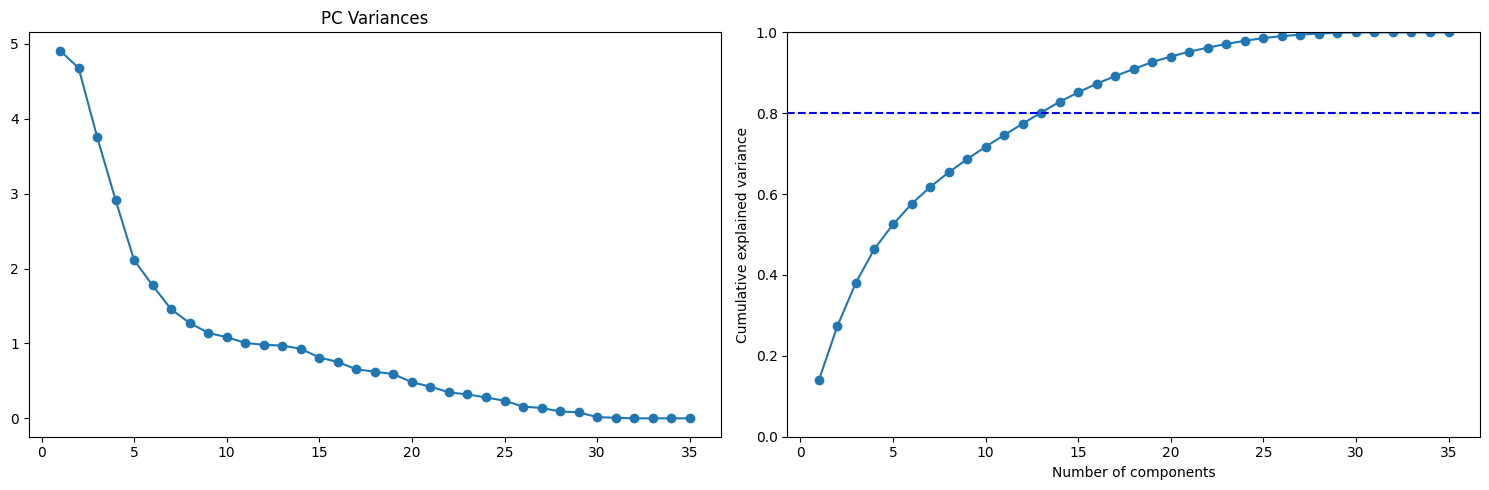

In [19]:
fig, axs = plt.subplots(1, 2, figsize=(15,5))
n, p = X.shape
axs[0].plot(np.arange(1, p+1), pca.explained_variance_, marker='o')
axs[0].set_title('PC Variances')
cum_explained = np.cumsum(pca.explained_variance_ratio_)
axs[1].plot(np.arange(1, p+1), cum_explained, marker='o')
axs[1].axhline(1, color='blue')
axs[1].axhline(0.8, color='blue', linestyle='--')
axs[1].set_xlabel('Number of components')
axs[1].set_ylabel('Cumulative explained variance')
axs[1].set_ylim(0,1)
plt.tight_layout()
plt.show()

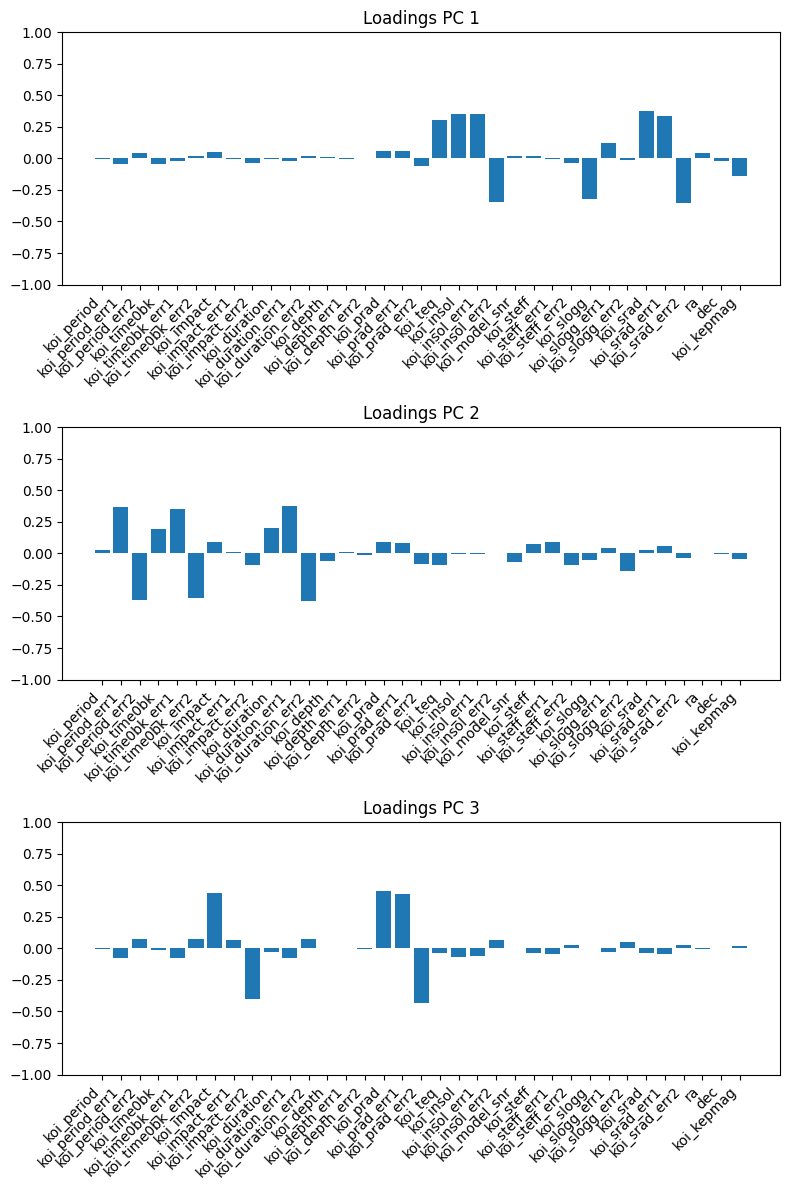

In [20]:
# Barplots of loadings for the first three PCs
fig, axs = plt.subplots(3, 1, figsize=(8,12))
for i in range(3):
    axs[i].bar(X.columns, loads[:, i])
    axs[i].set_ylim([-1, 1])
    axs[i].set_title(f'Loadings PC {i+1}')
    axs[i].tick_params(axis='x', rotation=45)
    plt.setp(axs[i].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

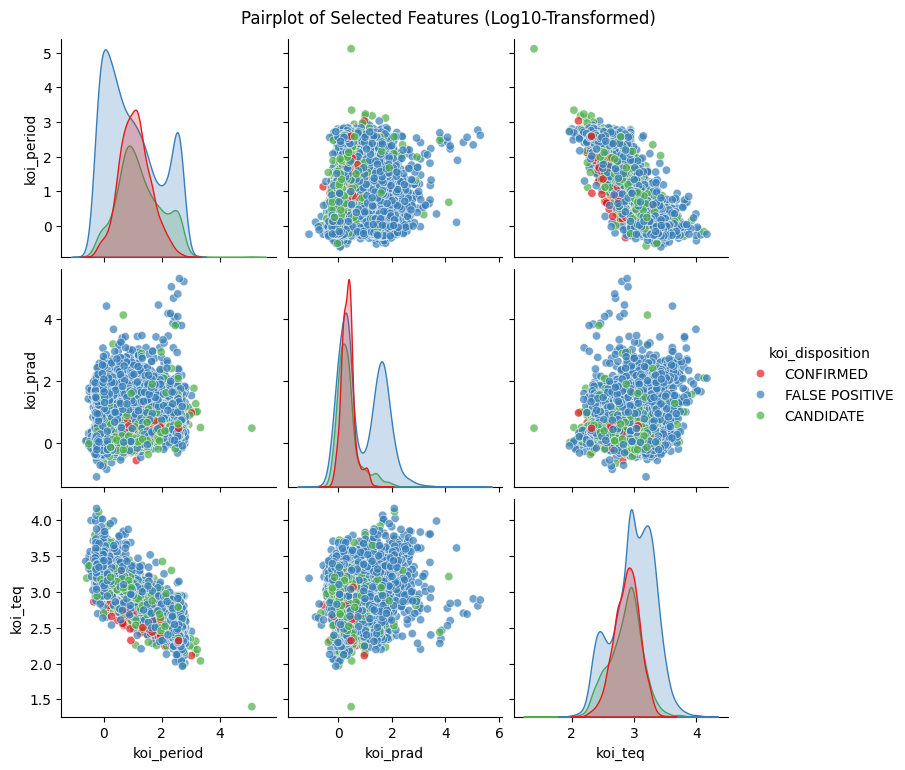

In [21]:
# --- Pairplot Analysis ---
# Feature Selection For Scatter Plots:
# 1. Physics: Radius/Period define the body; Temp define its energy.
# 2. Separation: False positives often show impossible radii, making them easy to spot.
# 3. Efficiency: Plotting only key pairs prevents visual clutter and kernel crashes.

vars_to_plot = ['koi_period', 'koi_prad', 'koi_teq']

# Use the UNSCALED dataframe for visualization (adjust 'df_imputed' to your actual unscaled dataframe name)
df_vis = df_imputed.copy()

# Now the log transformation will work correctly on the raw positive values
df_vis[vars_to_plot] = np.log10(df_vis[vars_to_plot] + 1e-5)

g = sns.pairplot(
    df_vis,
    vars=vars_to_plot,
    hue='koi_disposition',
    palette='Set1',
    plot_kws={
        'alpha': 0.7,
        'edgecolor': 'white',
        'linewidth': 0.5
    },
    diag_kind='kde'
)

g.figure.suptitle('Pairplot of Selected Features (Log10-Transformed)', y=1.02)
plt.show()

In [22]:
# --- Pairplot Results Analysis ---
# - The Power of Radius (koi_prad): The KDE plot for planetary radius reveals a
#   massive, distinct peak for False Positives (blue) at much higher values.
#   This confirms that anomalous size is the strongest indicator of a false alarm.
# - Clear Decision Boundaries: In the scatter plots, False Positives strongly
#   isolate themselves in the upper regions (high radius, high temp). This clear
#   spatial separation is excellent news for classification algorithms.
# - The Candidate Overlap: 'Candidate' objects (green) almost perfectly overlap
#   with 'Confirmed' planets (red). This makes physical sense, as candidates are
#   high-probability targets awaiting final validation, sharing the same traits.

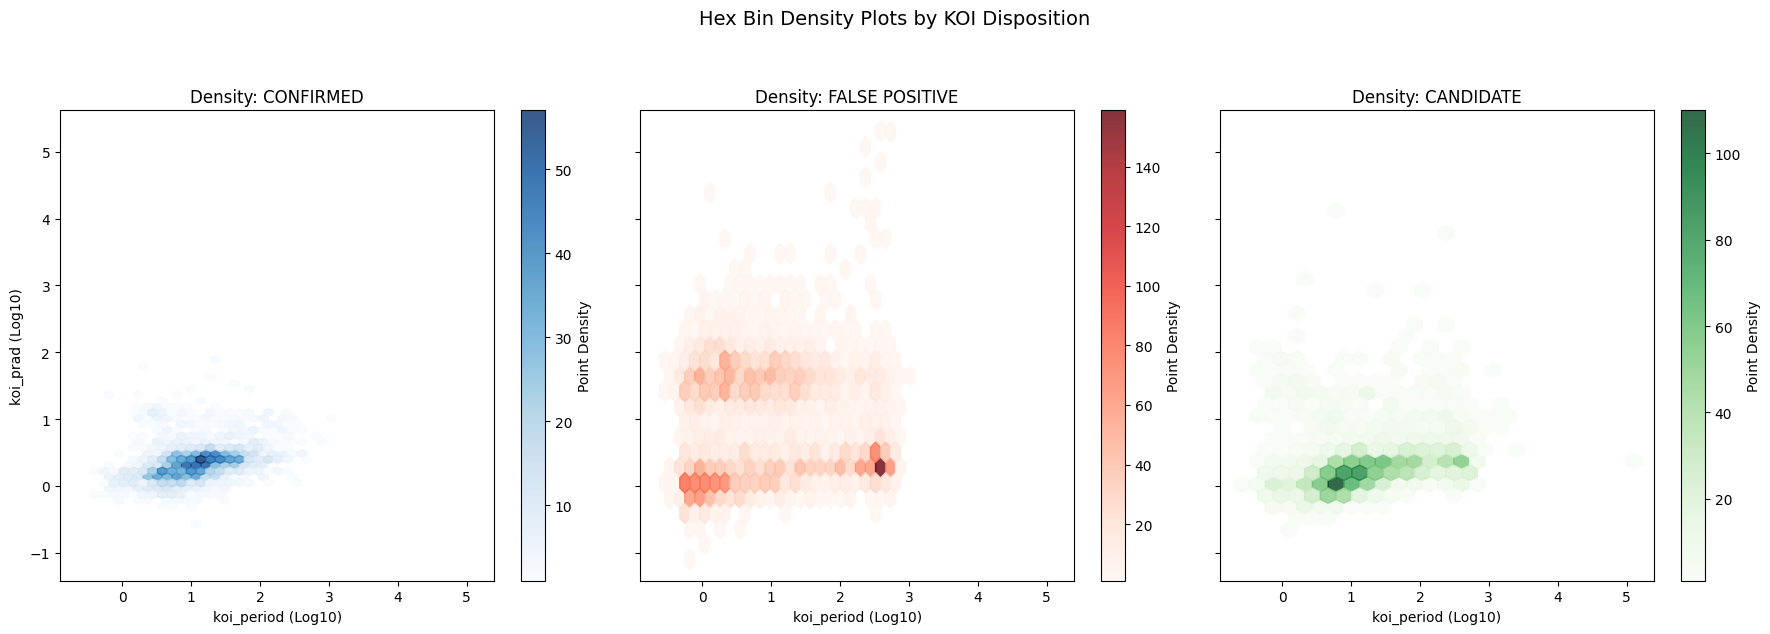

In [23]:
# --- Hex Bin Density Plots Analysis ---
# Define the classes to iterate through
classes = df_vis['koi_disposition'].unique()

# Set up a figure with 3 subplots side-by-side sharing the same axes
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6), sharex=True, sharey=True)

# Define distinct color maps for each class's density (e.g., Blues, Reds, Greens)
colormaps = ['Blues', 'Reds', 'Greens']

for ax, target_class, cmap in zip(axes, classes, colormaps):
    # Filter the dataset for the specific class
    subset = df_vis[df_vis['koi_disposition'] == target_class]

    # Generate the hex bin plot
    # gridsize: controls the size of the hexagons
    # mincnt=1: makes empty hexagons transparent instead of coloring them zero
    hb = ax.hexbin(
        subset['koi_period'],
        subset['koi_prad'],
        gridsize=25,
        cmap=cmap,
        mincnt=1,
        alpha=0.8
    )

    # Aesthetic adjustments
    ax.set_title(f'Density: {target_class}')
    ax.set_xlabel('koi_period (Log10)')
    if ax == axes[0]:
        ax.set_ylabel('koi_prad (Log10)')

    # Add a colorbar to show the density count scale for each plot
    fig.colorbar(hb, ax=ax, label='Point Density')

plt.suptitle('Hex Bin Density Plots by KOI Disposition', y=1.05, fontsize=14)
plt.tight_layout()
plt.show()

In [24]:
# --- Hex Bin Density Plots Results Analysis ---
# - Confirmed & Candidates Convergence: The density heatmaps reveal that the
#   "centers of mass" for both Confirmed (blue) and Candidate (green) objects
#   overlap almost perfectly at low planetary radii and short orbital periods.
#   Physically, they are indistinguishable in these two dimensions.
# - False Positive Divergence: The False Positive class (red) displays a
#   radically different spatial signature. Instead of a single low-radius core,
#   its density is distributed across distinct horizontal bands at much higher
#   radii, characteristic of eclipsing binary stars or instrumental anomalies.
# - Predictive Implications: A machine learning algorithm will easily isolate the
#   bulk of False Positives using planetary radius. However, separating
#   Confirmed planets from Candidates will require the model to rely heavily
#   on other, more subtle features in the dataset.

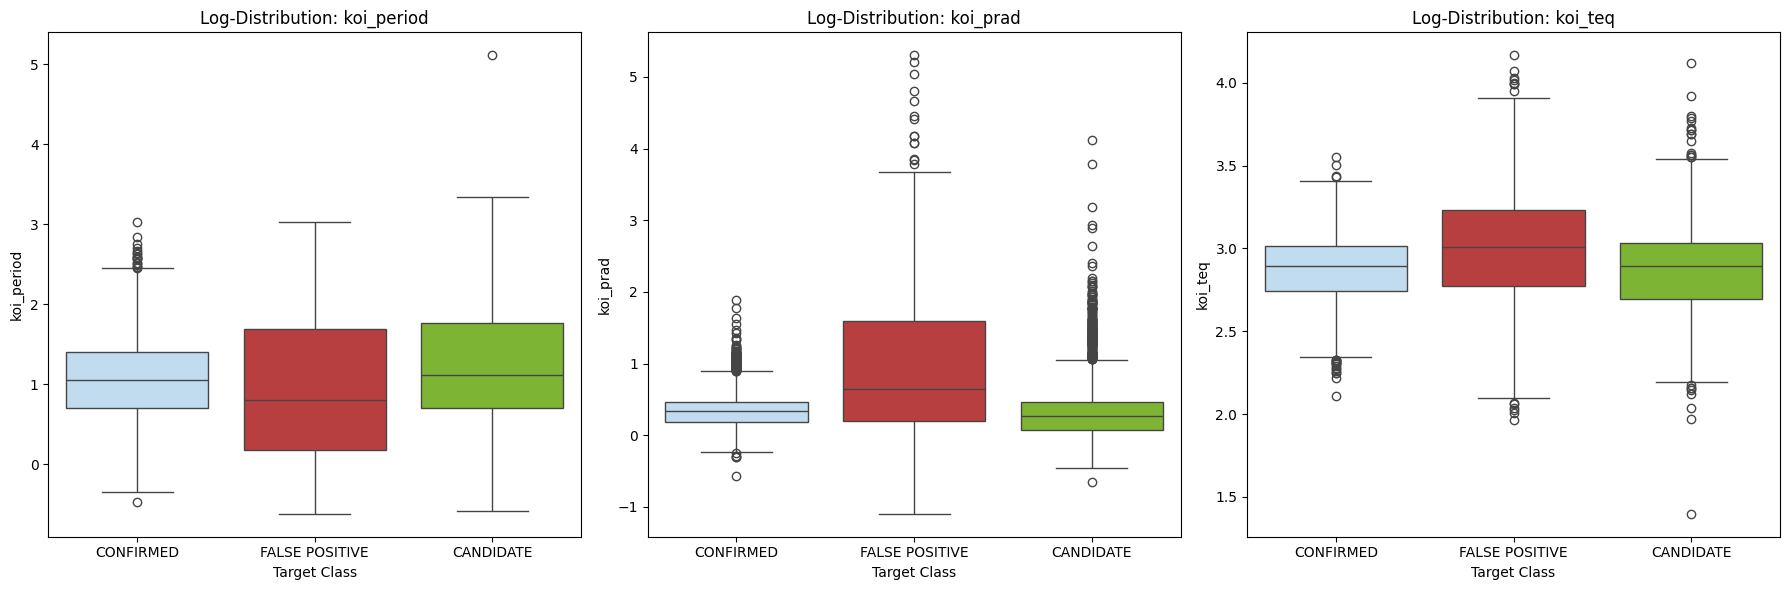

In [25]:
# --- Boxplot Analysis ---
# Log transformation to handle large scale disparities
df_log_transformed = df_imputed.copy()
log_features = ['koi_period', 'koi_prad', 'koi_teq']
df_log_transformed[log_features] = np.log10(df_log_transformed[log_features] + 1e-5)

# Official color palette
colors = ['#baddf5', '#cc2b2b', '#82c91e']
features = log_features

# Create the visualization grid
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))

for i, feature in enumerate(features):
    sns.boxplot(
        x="koi_disposition",
        y=feature,
        data=df_log_transformed,
        palette=colors,
        hue="koi_disposition",  # Correctly maps colors to classes
        legend=False,           # Removes duplicate legend
        ax=axes[i],
        showfliers=True         # Keeps outliers visible
    )

    axes[i].set_title(f'Log-Distribution: {feature}')
    axes[i].set_xlabel('Target Class')

plt.tight_layout()
plt.show()

In [26]:
# --- Boxplot Results Analysis ---
# - koi_prad: 'FALSE POSITIVE' (FP) shows a distinctly
# higher median and wider IQR. 'CONFIRMED' and 'CANDIDATE' overlap heavily
# at low radii, making them virtually indistinguishable on this feature alone.
# - koi_period: FP exhibits a much larger spread (taller
# box). 'CONFIRMED' and 'CANDIDATE' distributions remain nearly identical.
# - koi_teq: Massive overlap across all classes. Acts as a weak
# standalone separator but provides normal planetary physical bounds.
# - Outliers: The log10-transformation ensures points outside the whiskers
# are true statistical anomalies, which heavily concentrate in the FP class.

## Base model
Fit random forest model using $m = \sqrt{p}$, $m$ number of features to keep in each tree, $p$ number of features in the dataset. Recommended hyperparameters for classification model.

In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

num_features = len(X_train.columns)
rf = RandomForestClassifier(n_estimators=100, max_depth=5, max_features="sqrt", random_state=42)
rf.fit(X_train, y_train)

# Predict
y_pred = rf.predict(X_test)

# Evaluate
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=mapping.keys()))

Test Accuracy: 0.741

Classification Report:
                precision    recall  f1-score   support

     CANDIDATE       0.67      0.24      0.36       449
     CONFIRMED       0.75      0.79      0.77       459
FALSE POSITIVE       0.75      0.94      0.83      1005

      accuracy                           0.74      1913
     macro avg       0.72      0.66      0.65      1913
  weighted avg       0.73      0.74      0.71      1913



#### Choose hyperparameters
The result will be a model trained on all the features with tuned hyperparameters

In [36]:
from sklearn.model_selection import GridSearchCV

you_have_time = False

if you_have_time:
    param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 3, 5, 10],
    "max_features": ["sqrt", "log2", None, 0.8]
    }
    # Grid search
    rf = RandomForestClassifier(random_state=42)
    grid_search = GridSearchCV(
    rf,
    param_grid,
    verbose=3,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
    )
    grid_search.fit(X_train, y_train)
    # Best model
    best_rf = grid_search.best_estimator_
    print(f"Best Parameters: {grid_search.best_params_}")
    print(f"Best CV F1 Macro: {grid_search.best_score_:.3f}")
    # Test performance
    y_pred = best_rf.predict(X_test)
    print(f"\nTest Accuracy: {accuracy_score(y_test, y_pred):.3f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=mapping.keys()))

Using built in random forest feature importance. We can inspect the result for understanding what are the relevant features in the prediction. If two features are correlated the importance is splitted between the two

In [29]:
if you_have_time:
    importances = best_rf.feature_importances_
    sorted_idx = np.argsort(importances)
    plt.figure(figsize=(8, 6))
    plt.barh(np.array(X_train.columns)[sorted_idx], importances[sorted_idx])
    plt.xlabel("Feature importance")
    plt.title("Random Forest Feature Importance")
    plt.tight_layout()
    plt.show()

#### PCA used for for feature selection
We try to train the model only on the first 14 principal components. From the above graph, the one about explained variablity, we can see that those alone can explain more than 80% of variablity.

In [32]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

pca = PCA()
scores_train  = pca.fit_transform(X_train)
num_features = 14
rf = RandomForestClassifier(n_estimators=100, max_depth=5, max_features="sqrt", random_state=42)
rf.fit(scores_train[:, :num_features], y_train)

# Predict
rf.fit(scores_train[:, :num_features], y_train)
scores_test = pca.transform(X_test)
y_pred = rf.predict(scores_test[:, :num_features])

# Evaluate
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=mapping.keys()))

Test Accuracy: 0.666

Classification Report:
                precision    recall  f1-score   support

     CANDIDATE       0.64      0.02      0.03       449
     CONFIRMED       0.66      0.67      0.67       459
FALSE POSITIVE       0.67      0.95      0.79      1005

      accuracy                           0.67      1913
     macro avg       0.66      0.55      0.49      1913
  weighted avg       0.66      0.67      0.58      1913



The model perform worse than the base model.

In [ ]:
if you_have_time:
    param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 3, 5, 10],
    "max_features": ["sqrt", "log2", None, 0.8]
    }
    # Grid search
    rf = RandomForestClassifier(random_state=42)
    grid_search = GridSearchCV(
    rf,
    param_grid,
    verbose=3,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
    )
    grid_search.fit(scores_train, y_train)
    # Best model
    best_rf = grid_search.best_estimator_
    print(f"Best Parameters: {grid_search.best_params_}")
    print(f"Best CV F1 Macro: {grid_search.best_score_:.3f}")
    # Test performance
    y_pred = best_rf.predict(scores_test)
    print(f"\nTest Accuracy: {accuracy_score(y_test, y_pred):.3f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=mapping.keys()))

Fitting 5 folds for each of 48 candidates, totalling 240 fits
[CV 2/5] END max_depth=None, max_features=sqrt, n_estimators=50;, score=0.665 total time=   1.5s
[CV 5/5] END max_depth=None, max_features=sqrt, n_estimators=50;, score=0.657 total time=   1.6s
[CV 4/5] END max_depth=None, max_features=sqrt, n_estimators=50;, score=0.654 total time=   1.6s
[CV 1/5] END max_depth=None, max_features=sqrt, n_estimators=50;, score=0.664 total time=   1.7s
[CV 3/5] END max_depth=None, max_features=sqrt, n_estimators=50;, score=0.662 total time=   1.8s
[CV 4/5] END max_depth=None, max_features=sqrt, n_estimators=100;, score=0.658 total time=   3.1s
[CV 1/5] END max_depth=None, max_features=sqrt, n_estimators=100;, score=0.661 total time=   3.1s
[CV 2/5] END max_depth=None, max_features=sqrt, n_estimators=100;, score=0.677 total time=   3.2s
[CV 5/5] END max_depth=None, max_features=sqrt, n_estimators=100;, score=0.660 total time=   3.4s
[CV 3/5] END max_depth=None, max_features=sqrt, n_estimators=

With tuned hyperparams performs slightly better than base model but slightly worse than model with all features but tuned parameters

#### Feature selection using RFECV
Algorithm for feature selection based on random forest trees. We can use the result of this algorithm to select a subset of features

In [30]:
from sklearn.feature_selection import RFECV
rf_selector = RandomForestClassifier(n_estimators=50, random_state=42)
# RFECV automatically finds the optimal number of features using cross-validation
rfecv = RFECV(estimator=rf_selector, step=0.1, cv=5, scoring='accuracy')
rfecv.fit(X_train, y_train)

selected_features = X_train.columns[rfecv.support_].tolist()

In [31]:
selected_features

['koi_period',
 'koi_period_err1',
 'koi_period_err2',
 'koi_time0bk',
 'koi_time0bk_err1',
 'koi_time0bk_err2',
 'koi_impact',
 'koi_impact_err1',
 'koi_impact_err2',
 'koi_duration',
 'koi_duration_err1',
 'koi_duration_err2',
 'koi_depth',
 'koi_depth_err1',
 'koi_depth_err2',
 'koi_prad',
 'koi_prad_err1',
 'koi_prad_err2',
 'koi_teq',
 'koi_insol',
 'koi_insol_err1',
 'koi_model_snr',
 'koi_steff_err1',
 'koi_steff_err2',
 'koi_slogg_err2',
 'koi_srad_err1',
 'ra',
 'dec',
 'koi_kepmag']